In [1]:
# import the dataset.
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [2]:
# import the neccessary python libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# reading the data using pandas and stored it in df.
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
# Checking the shape of data how many rows and columns are there.
df.shape

(14999, 10)

In [5]:
# check if there any missing values.
df.isna().sum()
# no missing values are there.

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [6]:
# Count of employees who is willing to left the organisation.
df['left'].value_counts()

,count
left,
0,11428
1,3571


In [7]:
# a quick check for which factors are correlated to each other.
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


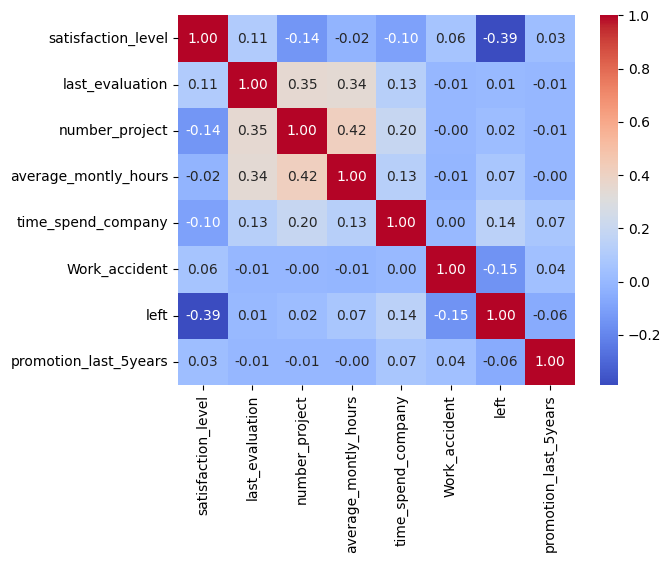

In [8]:
# visualisation of data through heatmap using data of correlation matrix.
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

In [9]:
# selecting columns which are responsible for employees stated and left.
dist_plots = ['satisfaction_level','last_evaluation','average_montly_hours']

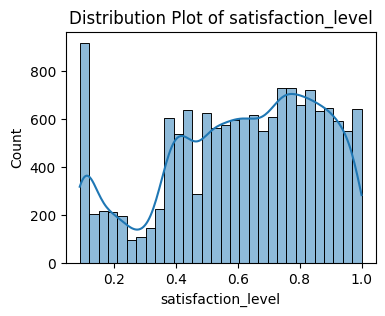

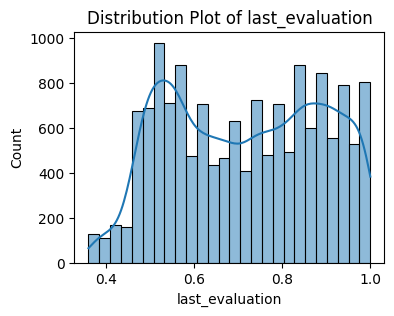

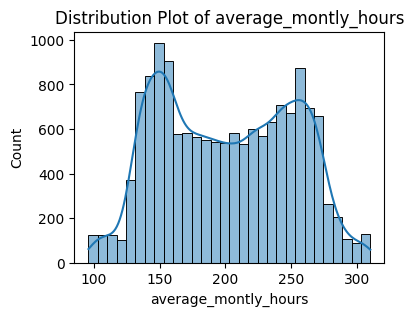

In [10]:
# creating the distribution plots of selected columns using for loop.
for col in dist_plots:
  plt.figure(figsize=(4,3))
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution Plot of {col}')
  plt.xlabel(col)
  plt.show()

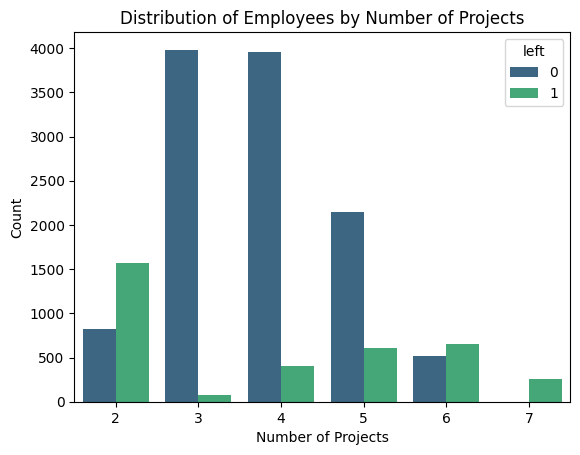

In [12]:
# visualisation of employees for how no. of projects affects the employees performance.
sns.countplot(data=df, x='number_project', hue='left', palette='viridis')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.title('Distribution of Employees by Number of Projects')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [13]:
# check how many unique values are present in specicified column.
df['sales'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [14]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [15]:
# assigning the object columns in a new variable.
obj_cols = ['sales', 'salary']

In [16]:
# applying the one hot encoding to the object columns and make the whole data numeric.
df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

In [17]:
# assigning the encoded columns in cat_cols .
cat_cols = [c for c in df.columns if c.startswith('sales_')] + [c for c in df.columns if c.startswith('salary_')]

In [19]:
# taking all numeric columns in num_cols except the encoded columns.
num_cols = df.drop(columns=cat_cols)

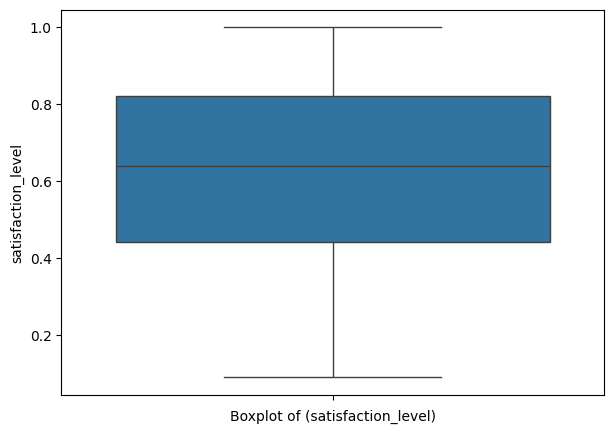

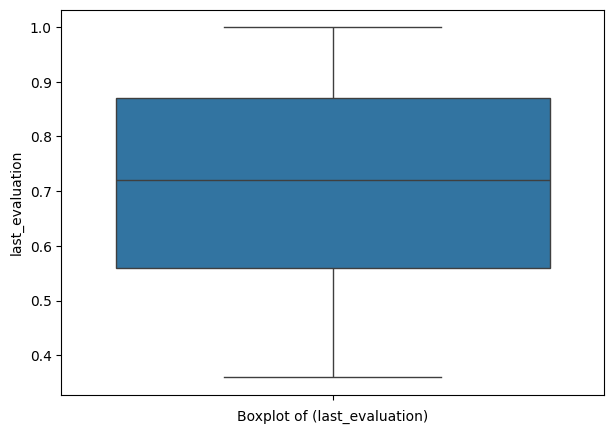

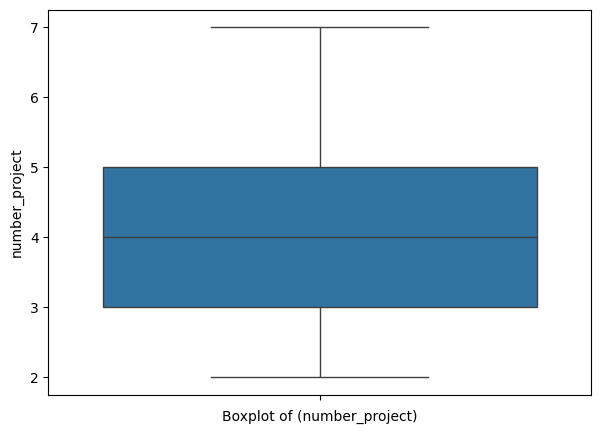

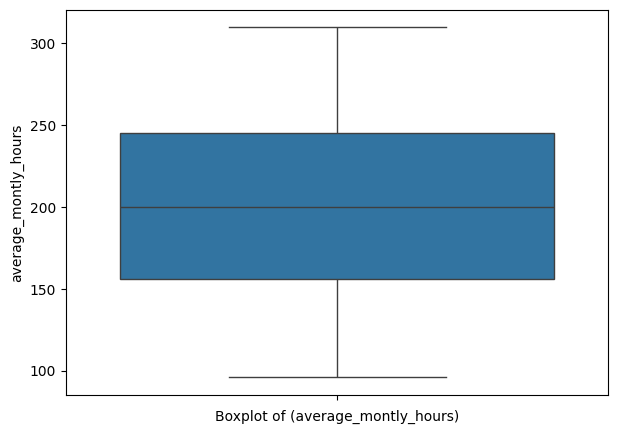

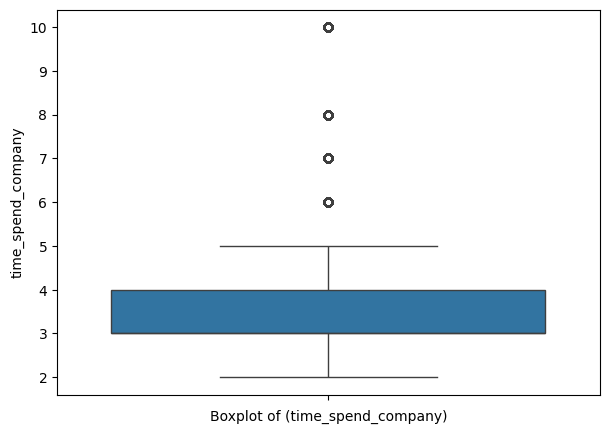

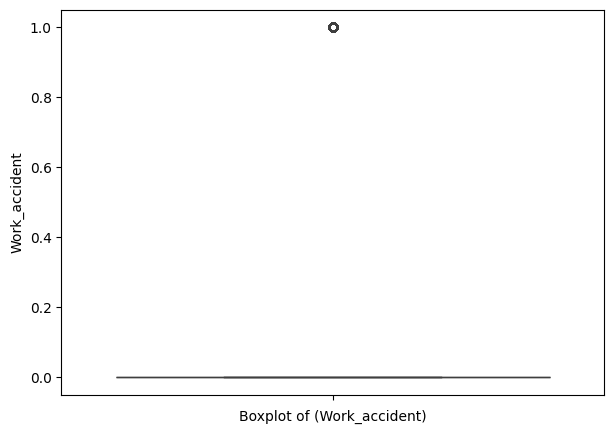

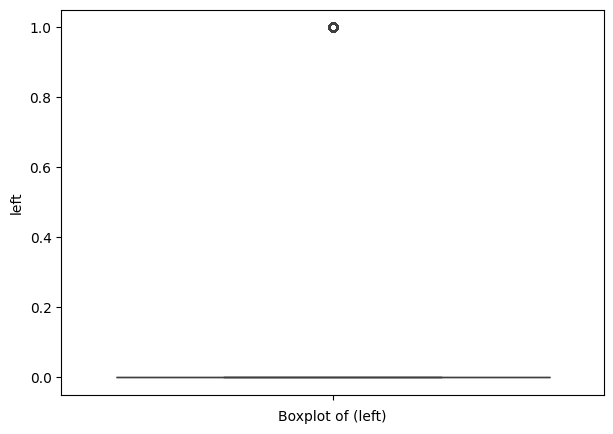

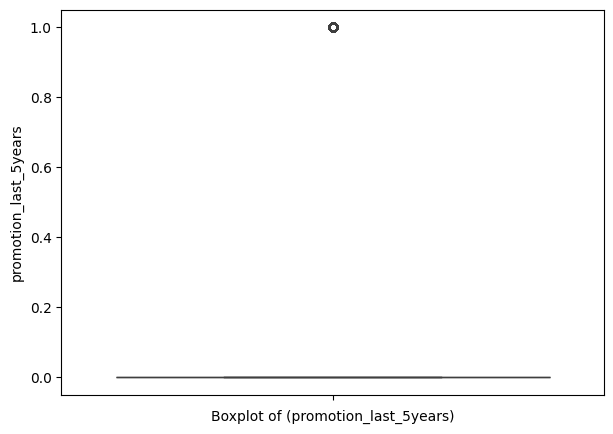

In [21]:
# using for loop for the visualisation of boxplots for check outliers for the columns contained in num_cols.
for col in num_cols:
  plt.figure(figsize=(7,5))
  sns.boxplot(df[col])
  plt.xlabel(f'Boxplot of ({col})')
  plt.show()

In [22]:
# count the outliers present in every column using for loop.
Outliers_cols = []
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  if outliers.shape[0] > 0:
   Outliers_cols.append(col)
   print(f'{col}: {outliers.shape[0]} outliers')


time_spend_company: 1282 outliers
Work_accident: 2169 outliers
left: 3571 outliers
promotion_last_5years: 319 outliers


In [26]:
'''
 Clip the outliers columns instead of removing them as meant not to loose a single data.
 the column left is also excluded form clipping because the employyed(left) are less compared to employees(stayed)
 because of that it converts all values of employees(left : 1) converted into employyes(stayed : 0) which changed my target data.

'''
df_clipped = df.copy()
clip_cols = [col for col in Outliers_cols if col!= 'left']
for col in clip_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clipped[col] = df_clipped[col].clip(lower=lower_bound, upper=upper_bound)

In [27]:
# checking that my target column remains same after clipping.
df_clipped['left'].unique()

array([1, 0])

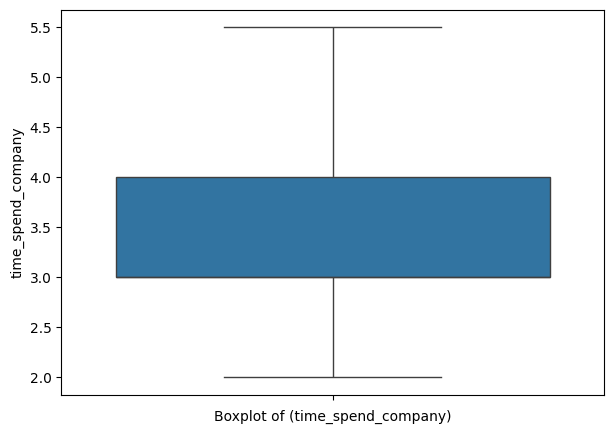

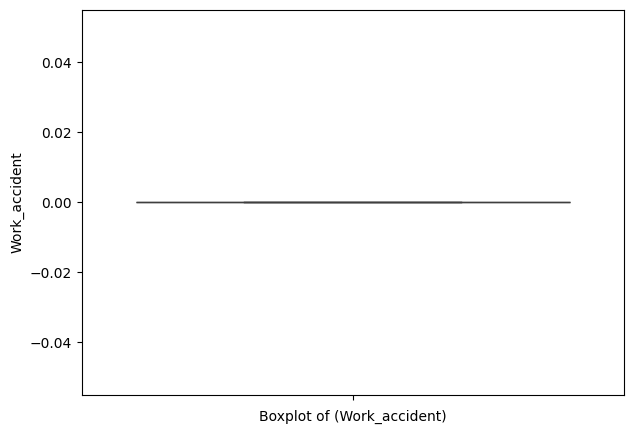

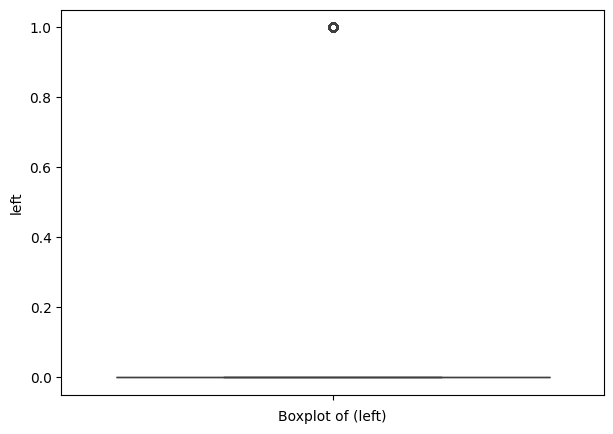

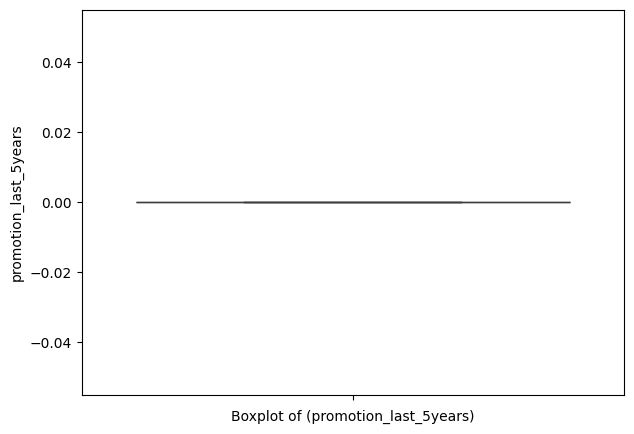

In [28]:
# checking the outliers columns are cclipped or not using for loop
for col in Outliers_cols:
  plt.figure(figsize=(7,5))
  sns.boxplot(df_clipped[col])
  plt.xlabel(f'Boxplot of ({col})')
  plt.show()

In [29]:
# seperating the left employyes only in left_df.
left_df= df_clipped[df_clipped['left'] == 1].copy()

In [31]:
x = left_df[['satisfaction_level','last_evaluation','left']]

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
km = KMeans(n_clusters=3, random_state=42)
scaler = StandardScaler()
(x_scaled) = scaler.fit_transform(x)

In [34]:
# applying k-means on the data and makes 3 cluters.
left_df['employees_cluster'] = km.fit_predict(x_scaled)
left_df['employees_cluster'].value_counts()

,count
employees_cluster,
0,1667
1,965
2,939


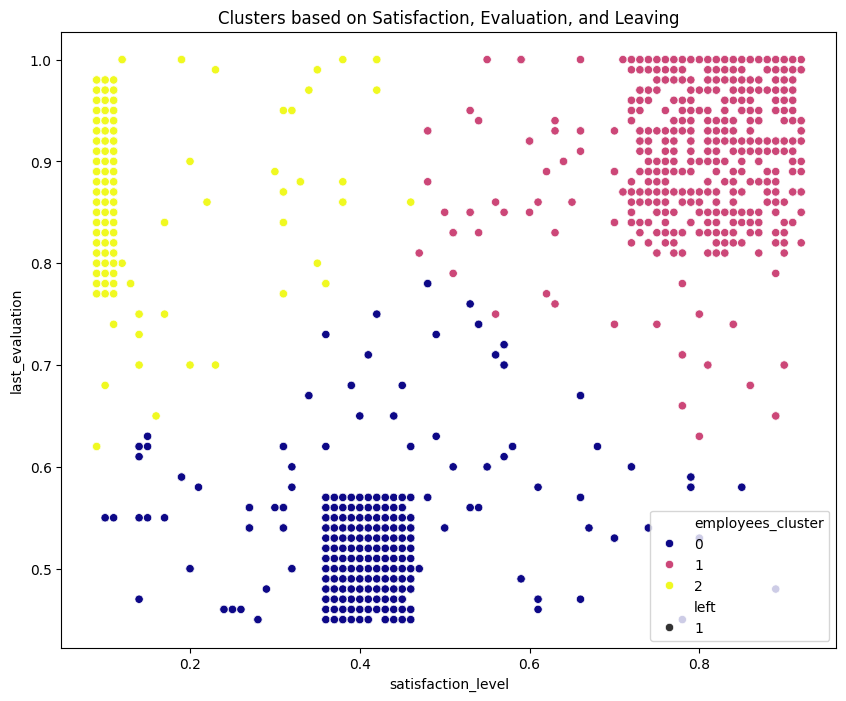

In [35]:
# visualisation of clusters through scatterplot.
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=left_df,
    x='satisfaction_level',
    y='last_evaluation',
    hue='employees_cluster',
    style='left',
    palette='plasma'
)
plt.title('Clusters based on Satisfaction, Evaluation, and Leaving')
plt.show()

In [36]:
# This will list every cluster and show the count for 0 and 1
left_df.groupby('employees_cluster')['left'].value_counts()


,,count
employees_cluster,left,
0,1,1667
1,1,965
2,1,939


In [37]:
X =df_clipped.drop(['left'],axis=1)
y = df_clipped['left']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=123, stratify=y)


In [39]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
model = {
    'linear':Pipeline([('scaler', StandardScaler()),
                  ('smote', SMOTE(random_state=123)),
                    ('lr', LogisticRegression())]),
    'rndm_forest' : Pipeline([('smote', SMOTE(random_state=123)),('rf', RandomForestClassifier())]),
    'gred_boost' : Pipeline([('smote', SMOTE(random_state=123)),('gb', GradientBoostingClassifier())])
}

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
for name, mdl in model.items():
  mdl.fit(X_train, y_train)
  y_pred = mdl.predict(X_test)
  print(f'{name} accuracy: {accuracy_score(y_test, y_pred)}')
  print(f'{name} confusion matrix: \n{confusion_matrix(y_test, y_pred)}')
  print(f'{name} classification report: \n{classification_report(y_test, y_pred)}')
  scores = cross_val_score(mdl, X, y, cv=5)
  print(f'{name} cross validation scores: {scores}')
  print(f'='*50)


linear accuracy: 0.7823333333333333
linear confusion matrix: 
[[1734  552]
 [ 101  613]]
linear classification report: 
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      2286
           1       0.53      0.86      0.65       714

    accuracy                           0.78      3000
   macro avg       0.74      0.81      0.75      3000
weighted avg       0.85      0.78      0.80      3000

linear cross validation scores: [0.798      0.80533333 0.8        0.80166667 0.68756252]
rndm_forest accuracy: 0.9906666666666667
rndm_forest confusion matrix: 
[[2273   13]
 [  15  699]]
rndm_forest classification report: 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000

rn

linear : 0.835182979578533


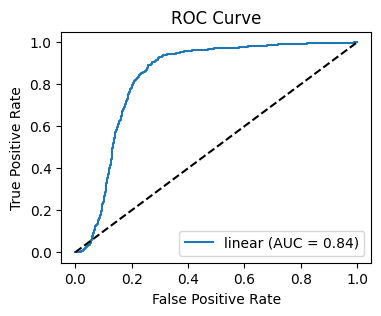

rndm_forest : 0.9949436467500385


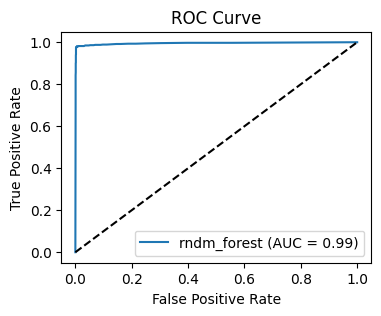

gred_boost : 0.9849767553565607


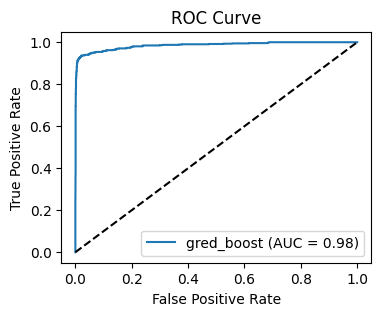

In [41]:
from sklearn.metrics import roc_auc_score, roc_curve
for name, mdl in model.items():
  mdl.fit(X_train, y_train)
  y_proba = mdl.predict_proba(X_test)[:,1]

  auc = roc_auc_score(y_test, y_proba)
  print(f'{name} : {auc}')

  fpr, tpr, thresholds = roc_curve(y_test, y_proba)
  plt.figure(figsize=(4,3))
  plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
  plt.plot([0,1], [0,1], 'k--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend()
  plt.show()


In [43]:
best_model = model['rndm_forest']
best_model.fit(X_train, y_train)
y_probs = best_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({'Probability': y_probs})

def categorize_zone(prob):
    if prob < 0.20: return 'Safe Zone (Green)'
    elif 0.20 < prob< 0.60: return 'Low-Risk Zone (Yellow)'
    elif 0.60 < prob < 0.90: return 'Medium-Risk Zone (Orange)'
    else: return 'High-Risk Zone (Red)'

results['Zone'] = results['Probability'].apply(categorize_zone)

print(results['Zone'].value_counts())

Zone
Safe Zone (Green)            2194
High-Risk Zone (Red)          663
Low-Risk Zone (Yellow)         85
Medium-Risk Zone (Orange)      58
Name: count, dtype: int64
